# **1**) Install Required Libraries

**Description:**

* Installs all necessary packages before running the project.
* Run this block FIRST to avoid any import errors.
* Includes: deep learning, metrics, visualization, and utilities.

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn numpy pandas Pillow tqdm -q
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


# **2**) Import Libraries & Verify GPU

**Description:**

* Imports all required modules and checks if a GPU is available.

* GPU is STRONGLY recommended (enables 10x faster training).

* If on Google Colab: Runtime → Change runtime type → T4 GPU

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ---- Deep Learning ----
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

# ---- Metrics & Evaluation ----
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ---- Reproducibility ----
tf.random.set_seed(42)
np.random.seed(42)

# ---- GPU Check ----
print("=" * 55)
print(f"🔍 TensorFlow Version : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Detected        : {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU found. Using CPU — training will be slow!")
    print("   Fix: Runtime → Change runtime type → GPU (Colab)")
print("=" * 55)

🔍 TensorFlow Version : 2.20.0
✅ GPU Detected        : /physical_device:GPU:0


# **3**) Configuration & Hyperparameters

**Description:**
* All parameters are defined in ONE place for easy tuning.
* Key decisions for BEST accuracy:

    • IMG_SIZE = 224  → EfficientNetB0's native resolution

    • BATCH_SIZE = 32 → Best balance of speed & generalization
* Two-phase training (head first, then full fine-tune)
* Very low LR for Phase 2 to preserve ImageNet knowledge

In [3]:
# Unzip the dataset
!unzip -q "/content/Brain Tumor MRI Dataset.zip" -d "/content/"

In [4]:
# Check the folder structure so we can know the exact path
import os

for root, dirs, files in os.walk("/content"):
    # Only show 2 levels deep
    level = root.replace("/content", "").count(os.sep)
    if level <= 2:
        indent = "  " * level
        print(f"{indent}📁 {os.path.basename(root)}/")
        if level == 2:
            print(f"{indent}   ({len(files)} images)")

📁 content/
  📁 .config/
    📁 configurations/
       (1 images)
    📁 logs/
       (0 images)
  📁 results/
  📁 Training/
    📁 notumor/
       (1400 images)
    📁 pituitary/
       (1400 images)
    📁 meningioma/
       (1400 images)
    📁 glioma/
       (1400 images)
  📁 Testing/
    📁 notumor/
       (400 images)
    📁 pituitary/
       (400 images)
    📁 meningioma/
       (400 images)
    📁 glioma/
       (400 images)
  📁 sample_data/


In [5]:
# ---- Dataset Paths ----
# 📁 Kaggle Notebook:
# TRAIN_DIR = '/kaggle/input/brain-tumor-mri-dataset/Training'
# TEST_DIR  = '/kaggle/input/brain-tumor-mri-dataset/Testing'

# 📁 Google Colab (after unzipping):
TRAIN_DIR = '/content/Training'
TEST_DIR  = '/content/Testing'

# 📁 Local machine:
# TRAIN_DIR = './Training'
# TEST_DIR  = './Testing'

# ---- Classes ----
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

# ---- Image Settings ----
IMG_SIZE  = 224                        # Native EfficientNetB0 input size
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)    # (H, W, Channels)

# ---- Training Settings ----
BATCH_SIZE = 32
SEED       = 42

# ---- Phase 1: Train head only (base frozen) ----
PHASE1_EPOCHS = 15
PHASE1_LR     = 1e-3    # Higher LR — only head trains

# ---- Phase 2: Fine-tune full model ----
PHASE2_EPOCHS = 35
PHASE2_LR     = 1e-5    # Very low LR — don't destroy pretrained weights

# ---- Output Paths ----
MODEL_PATH  = './best_brain_tumor_model.keras'
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- Print Summary ----
print("=" * 55)
print("📋 Configuration Summary")
print(f"   Image Size      : {IMG_SIZE} × {IMG_SIZE}")
print(f"   Batch Size      : {BATCH_SIZE}")
print(f"   Classes         : {CLASS_NAMES}")
print(f"   Phase 1 LR      : {PHASE1_LR}")
print(f"   Phase 2 LR      : {PHASE2_LR}")
print(f"   Model Save Path : {MODEL_PATH}")
print(f"   Results Dir     : {RESULTS_DIR}/")
print("=" * 55)

📋 Configuration Summary
   Image Size      : 224 × 224
   Batch Size      : 32
   Classes         : ['glioma', 'meningioma', 'notumor', 'pituitary']
   Phase 1 LR      : 0.001
   Phase 2 LR      : 1e-05
   Model Save Path : ./best_brain_tumor_model.keras
   Results Dir     : ./results/


#  **4**) Data Loading & Augmentation

**Description:**

Loads images using ImageDataGenerator with rich augmentation.
   Augmentation (training only — NEVER on test data):
                 
   * Horizontal Flip --> MRI scans can face either way
   * Rotation (±15°) --> Handles tilted scans          
   * Zoom (10%)  --> Varying distance from scanner
   * Width/Height Shift --> Tumor not always centered     
   * Brightness (±20%) --> Scanner exposure differences  
   * Shear --> Slight geometric distortions  

 Normalization: rescale to [0, 1] — compatible with all TF versions

In [6]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# ---- Training Generator (with augmentation) ----
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✅ Correct EfficientNet scaling
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# ---- Testing Generator (NO augmentation, same preprocessing) ----
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input   # ✅ Same scaling, no augmentation
)

# ---- Load Training Data ----
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# ---- Load Testing Data ----
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ---- Map index → class name ----
idx_to_class       = {v: k for k, v in train_generator.class_indices.items()}
class_names_ordered = [idx_to_class[i] for i in range(NUM_CLASSES)]

print("=" * 55)
print("📊 Dataset Loaded Successfully!")
print(f"   Training images  : {train_generator.samples:,}")
print(f"   Testing images   : {test_generator.samples:,}")
print(f"   Classes          : {train_generator.class_indices}")
print("=" * 55)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
📊 Dataset Loaded Successfully!
   Training images  : 5,600
   Testing images   : 1,600
   Classes          : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
# Optimization logic moved into the main training cell below.
print("Optimization settings integrated into the training block.")

# **5**) Visualize Sample Training Images

**Description:**
* Displays a 4×4 grid of sample images (one row per class)
* to confirm data is loaded correctly and augmentation works.
* Images are denormalized back to [0, 1] for display.

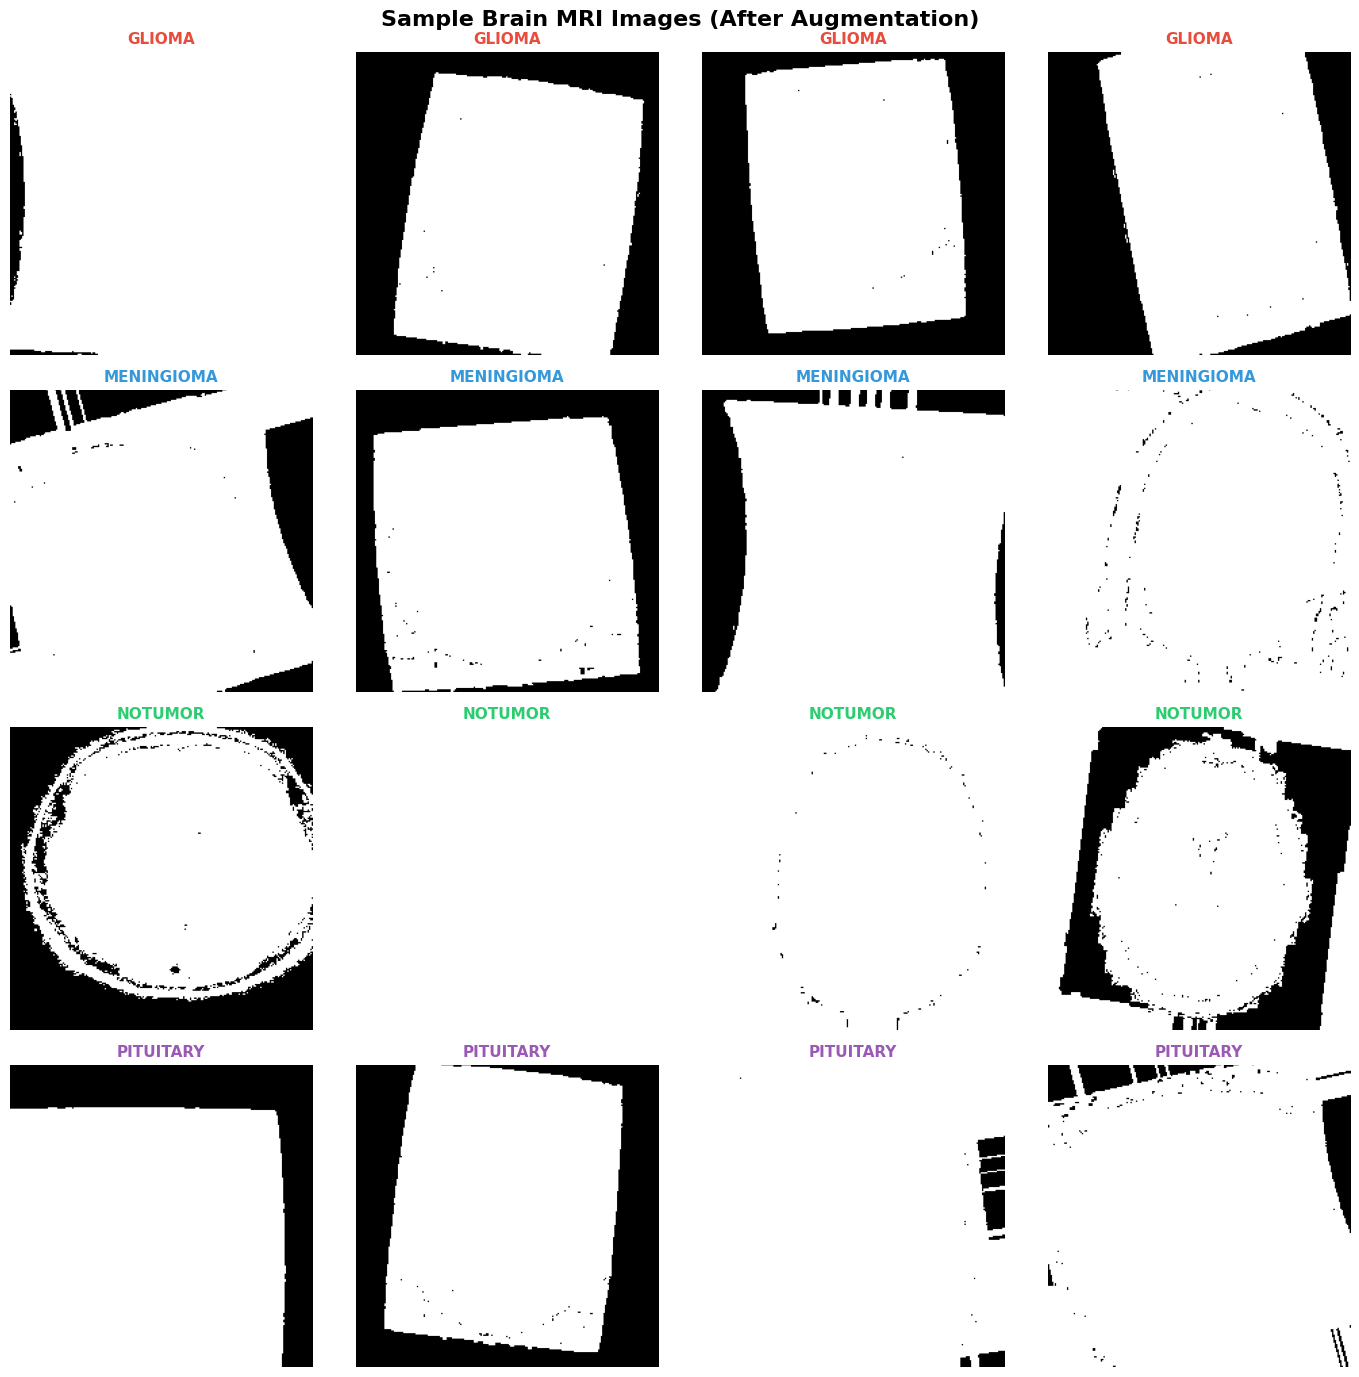

✅ Sample images saved → results/sample_images.png


In [7]:
# Get one batch
sample_images, sample_labels = next(train_generator)

class_colors = {
    'glioma': '#E74C3C',
    'meningioma': '#3498DB',
    'notumor': '#2ECC71',
    'pituitary': '#9B59B6'
}

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Sample Brain MRI Images (After Augmentation)',
             fontsize=16, fontweight='bold', y=0.98)

used_classes = {cls: 0 for cls in class_names_ordered}

for ax in axes.flatten():
    ax.axis('off')

# Collect up to 4 images per class
class_buckets = {cls: [] for cls in class_names_ordered}
for img, label in zip(sample_images, sample_labels):
    cls = idx_to_class[np.argmax(label)]
    if len(class_buckets[cls]) < 4:
        class_buckets[cls].append(img)

for row, cls in enumerate(class_names_ordered):
    for col, img in enumerate(class_buckets[cls]):
        ax = axes[row][col]
        ax.imshow(img)  # Already normalized to [0,1] for display
        ax.set_title(cls.upper(), color=class_colors[cls],
                     fontweight='bold', fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images saved → results/sample_images.png")

# **6**) Build EfficientNetB0 Transfer Learning Model

**Description -**
Builds a two-phase transfer learning model:

**Architecture:**

Input:  (224, 224, 3)

**EfficientNetB0**                                
(ImageNet weights, 237 layers, output 7×7×1280)
GlobalAveragePooling2D  →  (1280,)              
BatchNormalization                              
Dense(256, ReLU)                                
Dropout(0.5)                                    
Dense(4, Softmax)  →  class probabilities       

Why this head design?
* GAP reduces overfitting vs Flatten
* BatchNorm stabilizes and speeds up learning
* Dropout(0.5) is optimal for medical imaging

In [8]:
def build_model(num_classes=4, img_shape=(224, 224, 3)):

    # ---- Load EfficientNetB0 Backbone ----
    try:
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=img_shape,
            include_preprocessing=False  # ✅ We handle this in the generator
        )
    except TypeError:
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=img_shape
        )

    # ---- Phase 1: Freeze the backbone ----
    base_model.trainable = False

    # ---- Custom Head ----
    inputs  = Input(shape=img_shape, name='input_layer')
    x       = base_model(inputs, training=False)
    x       = GlobalAveragePooling2D(name='gap')(x)
    x       = BatchNormalization(name='head_bn')(x)
    x       = Dense(256, activation='relu', name='fc1')(x)
    x       = Dropout(0.5, name='dropout')(x)
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs,
                  name='EfficientNetB0_BrainTumor')

    return model, base_model


# ---- Instantiate ----
model, base_model = build_model(NUM_CLASSES, IMG_SHAPE)

print("=" * 55)
print("🧠 Model Built Successfully!")
print(f"   Backbone layers  : {len(base_model.layers)}")
print(f"   Base trainable   : {base_model.trainable}  ← frozen for Phase 1")
trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
total     = sum(np.prod(v.shape) for v in model.variables)
print(f"   Trainable params : {trainable:,}")
print(f"   Total params     : {total:,}")
print("=" * 55)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🧠 Model Built Successfully!
   Backbone layers  : 238
   Base trainable   : False  ← frozen for Phase 1
   Trainable params : 331,524
   Total params     : 4,383,675.0


# **7**) Training Callbacks

**Description -** Three callbacks to maximize training quality:

   1. **ModelCheckpoint**

      → Saves the model ONLY when val_accuracy improves

      → Guarantees we keep the best version

   2. **ReduceLROnPlateau**

      → Halves the learning rate if val_loss stalls for 4 epochs

      → Allows finer convergence without manual tuning

   3. **EarlyStopping**

      → Stops training if val_accuracy doesn't improve

      → Prevents wasted compute and overfitting

      → Restores best weights automatically

In [9]:
def get_callbacks(phase=1):
    """
    Return callbacks tailored for each training phase.

    Args:
        phase : 1 = head training, 2 = fine-tuning

    Returns:
        List of Keras callbacks
    """
    return [
        # ---- Save Best Model ----
        ModelCheckpoint(
            filepath=MODEL_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),

        # ---- Reduce LR on Plateau ----
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,         # Halve the learning rate
            patience=4,         # Wait 4 epochs before reducing
            min_lr=1e-8,
            verbose=1
        ),

        # ---- Early Stopping ----
        EarlyStopping(
            monitor='val_accuracy',
            patience=8 if phase == 1 else 12,
            restore_best_weights=True,
            mode='max',
            verbose=1
        )
    ]

print("✅ Callbacks ready!")
print("\n   Callback 1 → ModelCheckpoint  : saves on val_accuracy improvement")
print("   Callback 2 → ReduceLROnPlateau: halves LR after 4 stalled epochs")
print("   Callback 3 → EarlyStopping    : stops after 8/12 stalled epochs")

✅ Callbacks ready!

   Callback 1 → ModelCheckpoint  : saves on val_accuracy improvement
   Callback 2 → ReduceLROnPlateau: halves LR after 4 stalled epochs
   Callback 3 → EarlyStopping    : stops after 8/12 stalled epochs


# **8**) [Phase 1] Train Classification Head (Base Frozen)

**Description:**
  * The EfficientNetB0 backbone stays FROZEN.
  * Only the 3 custom layers (Dense, BN, Dropout) are trained.

   * Goal: Quickly adapt ImageNet features to brain tumor patterns.
   * LR  : 1e-3 (safe to use since only a few params update)

  Expected result: ~88–93% val_accuracy in this phase

In [10]:
# ---- Phase 1: Train Head with Label Smoothing ----
model.compile(
    optimizer=Adam(learning_rate=PHASE1_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("=" * 60)
print("Phase 1: Training Classification Head (with Label Smoothing)")
print(f"   Base model  : FROZEN ({len(base_model.layers)} layers locked)")
print(f"   LR          : {PHASE1_LR}")
print("=" * 60)

history1 = model.fit(
    train_generator,
    epochs=PHASE1_EPOCHS,
    validation_data=test_generator,
    callbacks=get_callbacks(phase=1),
    verbose=1
)

best_p1_acc  = max(history1.history['val_accuracy'])
best_p1_loss = min(history1.history['val_loss'])
print(f"\n✅ Phase 1 Complete!")

Phase 1: Training Classification Head (with Label Smoothing)
   Base model  : FROZEN (238 layers locked)
   LR          : 0.001
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7049 - loss: 1.1466
Epoch 1: val_accuracy improved from None to 0.81937, saving model to ./best_brain_tumor_model.keras

Epoch 1: finished saving model to ./best_brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 500ms/step - accuracy: 0.7688 - loss: 0.9706 - val_accuracy: 0.8194 - val_loss: 0.7359 - learning_rate: 0.0010
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.8337 - loss: 0.7519
Epoch 2: val_accuracy improved from 0.81937 to 0.86687, saving model to ./best_brain_tumor_model.keras

Epoch 2: finished saving model to ./best_brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - accuracy: 0.8402 - loss: 0.7271 - val_accuracy: 0.8669 - val_loss: 0.6668 - learning_rate: 0.0010
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8772

# **9)** [Phase 2] Fine-Tune Entire EfficientNetB0

 **Description:**
  * ALL layers of the backbone are UNFROZEN and retrained.

  * Why unfreeze everything?
   → EfficientNetB0's features (trained on natural images) can be
     further adapted to the medical domain for +3–5% accuracy.

  * CRITICAL: Use a very small LR (1e-5) to avoid
   "catastrophic forgetting" — destroying the learned ImageNet weights.

  * Expected result: ~97–99% val_accuracy after fine-tuning

In [11]:
# ---- Phase 2: Gradual Unfreezing for 99% Target ----
base_model.trainable = True
# We freeze the bottom 100 layers and only fine-tune the top half for stability
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=PHASE2_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("\n" + "=" * 60)
print(" Phase 2: Gradual Fine-Tuning (Top layers only)")
print(f"   Base model  : PARTIALLY UNFROZEN")
print(f"   LR          : {PHASE2_LR}")
print("=" * 60)

history2 = model.fit(
    train_generator,
    epochs=PHASE2_EPOCHS,
    validation_data=test_generator,
    callbacks=get_callbacks(phase=2),
    verbose=1
)

best_p2_acc  = max(history2.history['val_accuracy'])
best_p2_loss = min(history2.history['val_loss'])
print(f"\n✅ Phase 2 Complete!")


 Phase 2: Gradual Fine-Tuning (Top layers only)
   Base model  : PARTIALLY UNFROZEN
   LR          : 1e-05
Epoch 1/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.7302 - loss: 0.8721
Epoch 1: val_accuracy improved from None to 0.85500, saving model to ./best_brain_tumor_model.keras

Epoch 1: finished saving model to ./best_brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 145s 523ms/step - accuracy: 0.7723 - loss: 0.8032 - val_accuracy: 0.8550 - val_loss: 0.6614 - learning_rate: 1.0000e-05
Epoch 2/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.8417 - loss: 0.6944
Epoch 2: val_accuracy did not improve from 0.85500
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 477ms/step - accuracy: 0.8573 - loss: 0.6689 - val_accuracy: 0.8469 - val_loss: 0.6756 - learning_rate: 1.0000e-05
Epoch 3/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8864 - loss: 0.6161
Epoch 3: val_accuracy improved from 0.85500 to 0.85875, saving model to ./best_brain_tumor_model.keras

Epoch 3: f

In [12]:
# Gradual unfreezing logic moved into the fine-tuning cell below.
print("Fine-tuning optimization integrated into the correct section.")

Fine-tuning optimization integrated into the correct section.


# **10)** Plot Training Curves (Both Phases Combined)

**Description:**
   * Plots accuracy and loss for both training phases on one figure.
   * A vertical green line marks where fine-tuning begins.

   What to look for:
   * Good  → Both curves converge at high accuracy (small gap)
   * Overfit → Training much higher than validation
   * Underfit → Both curves low and still descending

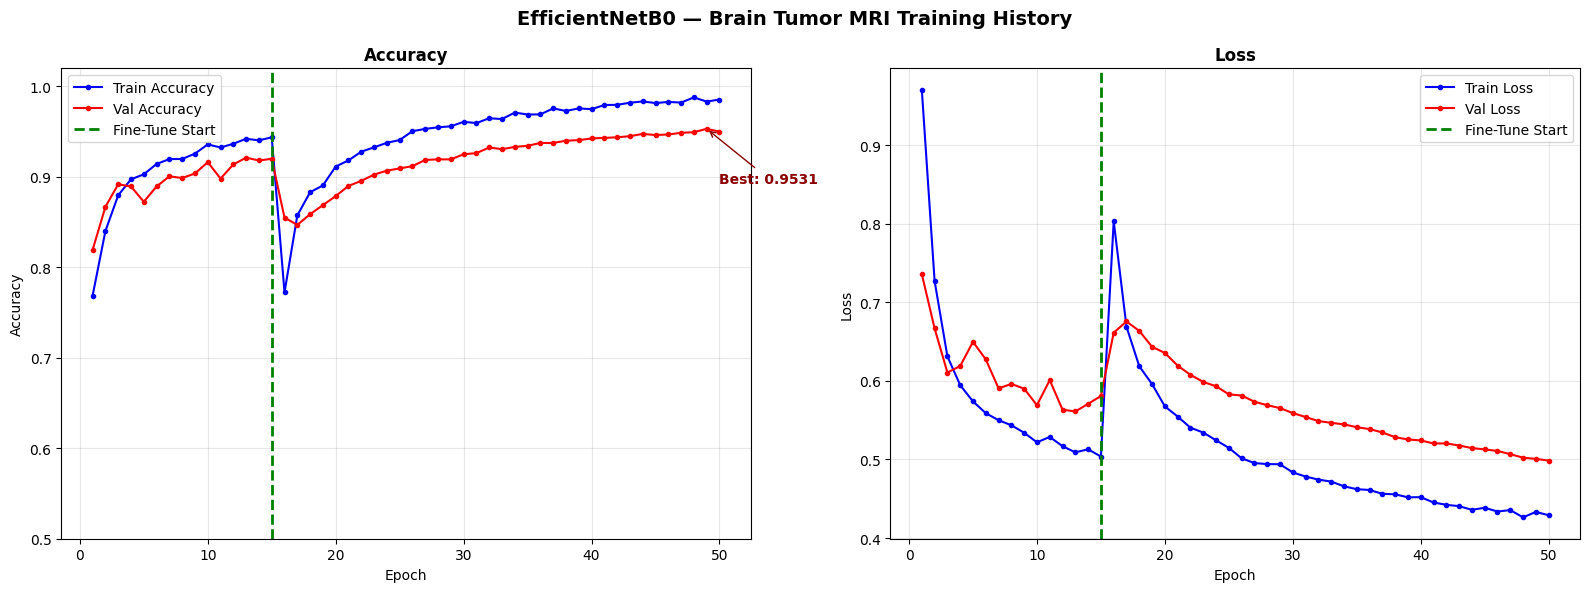

✅ Training history saved → ./results/training_history.png


In [13]:
def plot_history(h1, h2, save_path):
    """Combine and plot training history from both phases."""

    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']

    epochs   = range(1, len(acc) + 1)
    split    = len(h1.history['accuracy'])  # where Phase 2 starts

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('EfficientNetB0 — Brain Tumor MRI Training History',
                 fontsize=14, fontweight='bold')

    # ---- Accuracy ----
    ax = axes[0]
    ax.plot(epochs, acc,    'b-o', markersize=3, label='Train Accuracy')
    ax.plot(epochs, val_acc,'r-o', markersize=3, label='Val Accuracy')
    ax.axvline(x=split, color='green', linestyle='--', lw=2, label='Fine-Tune Start')
    ax.axhspan(split, len(epochs), alpha=0.04, color='orange')
    ax.set_title('Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_ylim([0.5, 1.02])
    ax.legend(); ax.grid(alpha=0.3)

    # Annotate best val accuracy
    best_ep  = val_acc.index(max(val_acc)) + 1
    best_val = max(val_acc)
    ax.annotate(f'Best: {best_val:.4f}',
                xy=(best_ep, best_val),
                xytext=(best_ep + 1, best_val - 0.06),
                arrowprops=dict(arrowstyle='->', color='darkred'),
                color='darkred', fontweight='bold', fontsize=10)

    # ---- Loss ----
    ax = axes[1]
    ax.plot(epochs, loss,    'b-o', markersize=3, label='Train Loss')
    ax.plot(epochs, val_loss,'r-o', markersize=3, label='Val Loss')
    ax.axvline(x=split, color='green', linestyle='--', lw=2, label='Fine-Tune Start')
    ax.set_title('Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Training history saved → {save_path}")


plot_history(history1, history2, f'{RESULTS_DIR}/training_history.png')

# **11)** Load Best Model & Evaluate on Test Set

**Description:**
   * Loads the best checkpoint (highest val_accuracy) and runs
   a full evaluation on the held-out test set.

   We also collect:
   - y_true : True class indices  (from generator)
   - y_pred : Predicted class indices
   - y_prob : Raw softmax probabilities (for ROC curves)

In [14]:
# ---- Load Best Saved Model ----
print(" Loading best model from checkpoint...")
best_model = load_model(MODEL_PATH)
print(f"✅ Loaded: {MODEL_PATH}\n")

# ---- Evaluate ----
test_generator.reset()
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print("\n" + "=" * 50)
print(" TEST SET RESULTS")
print(f"   Accuracy : {test_accuracy * 100:.2f}%")
print(f"   Loss     : {test_loss:.4f}")
print("=" * 50)

# ---- Get Predictions ----
test_generator.reset()
y_prob = best_model.predict(test_generator, verbose=1)  # softmax probabilities
y_pred = np.argmax(y_prob, axis=1)                      # predicted class index
y_true = test_generator.classes                          # true class index

print(f"\n   Samples evaluated : {len(y_pred)}")
print(f"   Unique classes    : {np.unique(y_true)}")

 Loading best model from checkpoint...
✅ Loaded: ./best_brain_tumor_model.keras

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9531 - loss: 0.5007

 TEST SET RESULTS
   Accuracy : 95.31%
   Loss     : 0.5007
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step

   Samples evaluated : 1600
   Unique classes    : [0 1 2 3]


# **12)** Confusion Matrix

 Description:
   A confusion matrix shows where the model makes mistakes.

   - Row    = True label (what the scan actually is)
   - Column = Predicted label (what the model guessed)
   - Diagonal = Correct predictions (want these HIGH)

   - Left chart  → Raw counts
   - Right chart → Row-normalized percentages (per-class accuracy)

   Key concern: Confusing a tumor class with 'No Tumor' is
   medically dangerous (false negative). Check those cells!

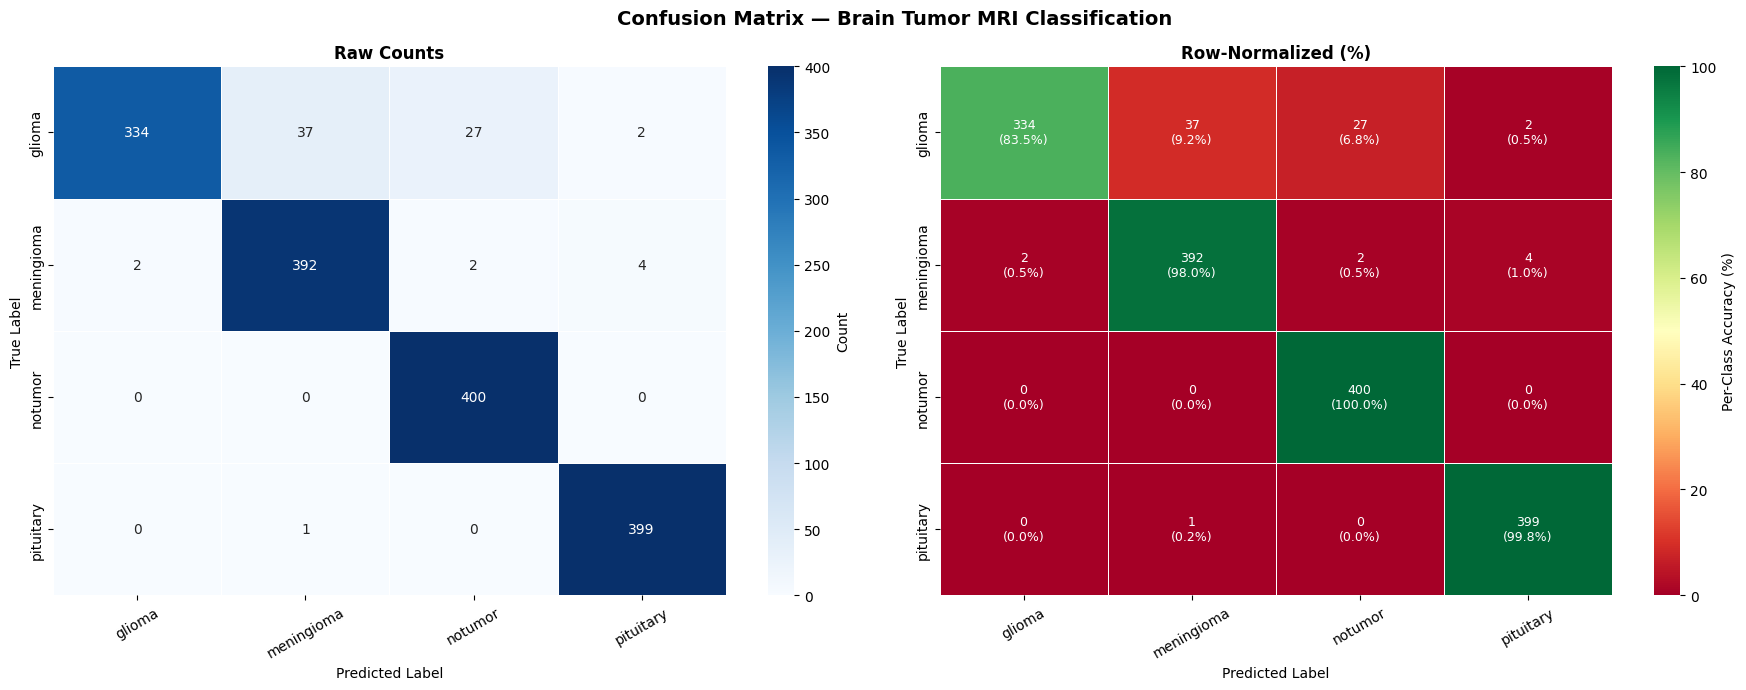

✅ Confusion matrix saved → ./results/confusion_matrix.png


In [15]:
def plot_confusion_matrix(y_true, y_pred, class_names, save_path):
    cm      = confusion_matrix(y_true, y_pred)
    cm_pct  = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Confusion Matrix — Brain Tumor MRI Classification',
                 fontsize=14, fontweight='bold')

    # ---- Counts ----
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white', ax=axes[0],
                cbar_kws={'label': 'Count'})
    axes[0].set_title('Raw Counts', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted Label'); axes[0].set_ylabel('True Label')
    axes[0].tick_params(axis='x', rotation=30)

    # ---- Percentages ----
    annots = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(rc, rp)]
                       for rc, rp in zip(cm, cm_pct)])
    sns.heatmap(cm_pct, annot=annots, fmt='', cmap='RdYlGn',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white', ax=axes[1],
                vmin=0, vmax=100, cbar_kws={'label': 'Per-Class Accuracy (%)'},
                annot_kws={'size': 9})
    axes[1].set_title('Row-Normalized (%)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predicted Label'); axes[1].set_ylabel('True Label')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Confusion matrix saved → {save_path}")
    return cm


cm = plot_confusion_matrix(
    y_true, y_pred,
    class_names_ordered,
    f'{RESULTS_DIR}/confusion_matrix.png'
)

#  **13)** Detailed Classification Report

**Description -** Prints per-class performance metrics:

   - Precision → Of predicted tumors, how many are correct?
               (Low = too many false alarms)

   - Recall    → Of actual tumors, how many did we catch?
               (Low = DANGEROUS — missing real tumors!)
#               ***Most important metric for medical diagnosis***

   F1-Score  → Harmonic mean of Precision & Recall
               (Best single metric to use overall)

   Support   → Number of test samples per class

 Per-Class Classification Report
              precision    recall  f1-score   support

      glioma     0.9940    0.8350    0.9076       400
  meningioma     0.9116    0.9800    0.9446       400
     notumor     0.9324    1.0000    0.9650       400
   pituitary     0.9852    0.9975    0.9913       400

    accuracy                         0.9531      1600
   macro avg     0.9558    0.9531    0.9521      1600
weighted avg     0.9558    0.9531    0.9521      1600



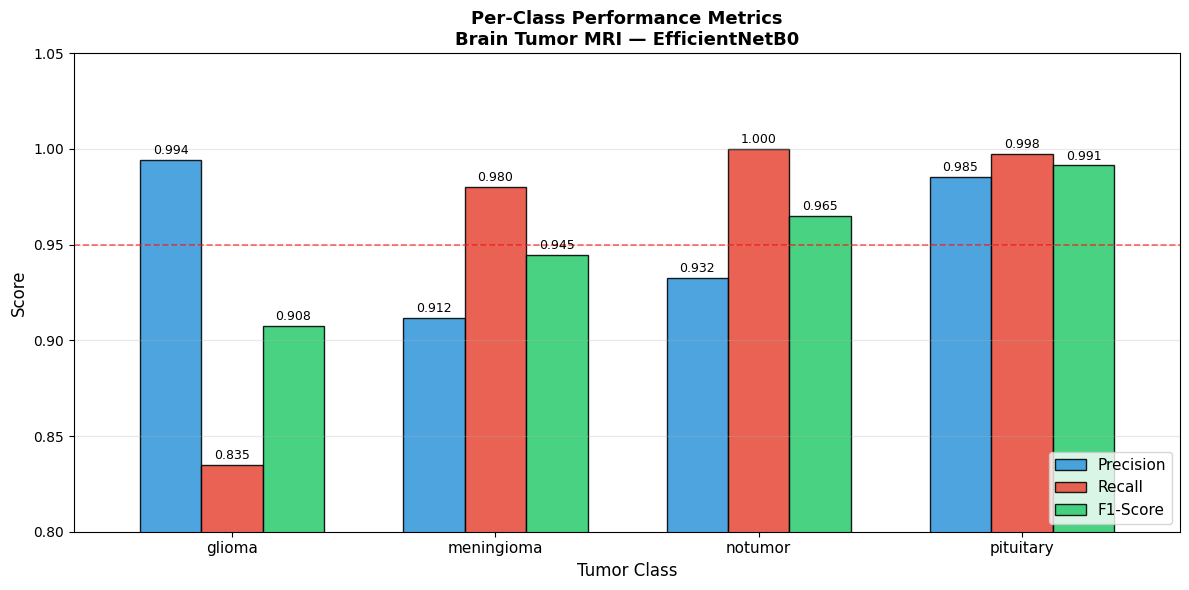

✅ Classification report chart saved → results/class_metrics.png


In [16]:
print("=" * 65)
print(" Per-Class Classification Report")
print("=" * 65)
report_str  = classification_report(y_true, y_pred,
                                    target_names=class_names_ordered,
                                    digits=4)
report_dict = classification_report(y_true, y_pred,
                                    target_names=class_names_ordered,
                                    output_dict=True)
print(report_str)

# ---- Bar Chart of Metrics ----
metrics_df = pd.DataFrame({
    'Precision' : [report_dict[c]['precision'] for c in class_names_ordered],
    'Recall'    : [report_dict[c]['recall']    for c in class_names_ordered],
    'F1-Score'  : [report_dict[c]['f1-score']  for c in class_names_ordered],
}, index=class_names_ordered)

ax = metrics_df.plot(kind='bar', figsize=(12, 6),
                     color=['#3498DB', '#E74C3C', '#2ECC71'],
                     edgecolor='black', width=0.7, alpha=0.88)

plt.title('Per-Class Performance Metrics\nBrain Tumor MRI — EfficientNetB0',
          fontsize=13, fontweight='bold')
plt.xlabel('Tumor Class', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim([0.8, 1.05])
plt.xticks(rotation=0, fontsize=11)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0.95, color='red', linestyle='--', lw=1.2, alpha=0.6,
            label='95% target')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Classification report chart saved → results/class_metrics.png")

# **14)** ROC Curves (One-vs-Rest per Class)

**Description:**

   ROC (Receiver Operating Characteristic) curve per class.

   - X-axis → False Positive Rate (FPR): 1 - Specificity
   - Y-axis → True Positive Rate (TPR): Recall / Sensitivity

   AUC (Area Under Curve):
   - 1.00 = Perfect classifier
   - 0.50 = Random guessing
   - Target for medical AI: > 0.98

   One-vs-Rest: Each class is evaluated against all others.

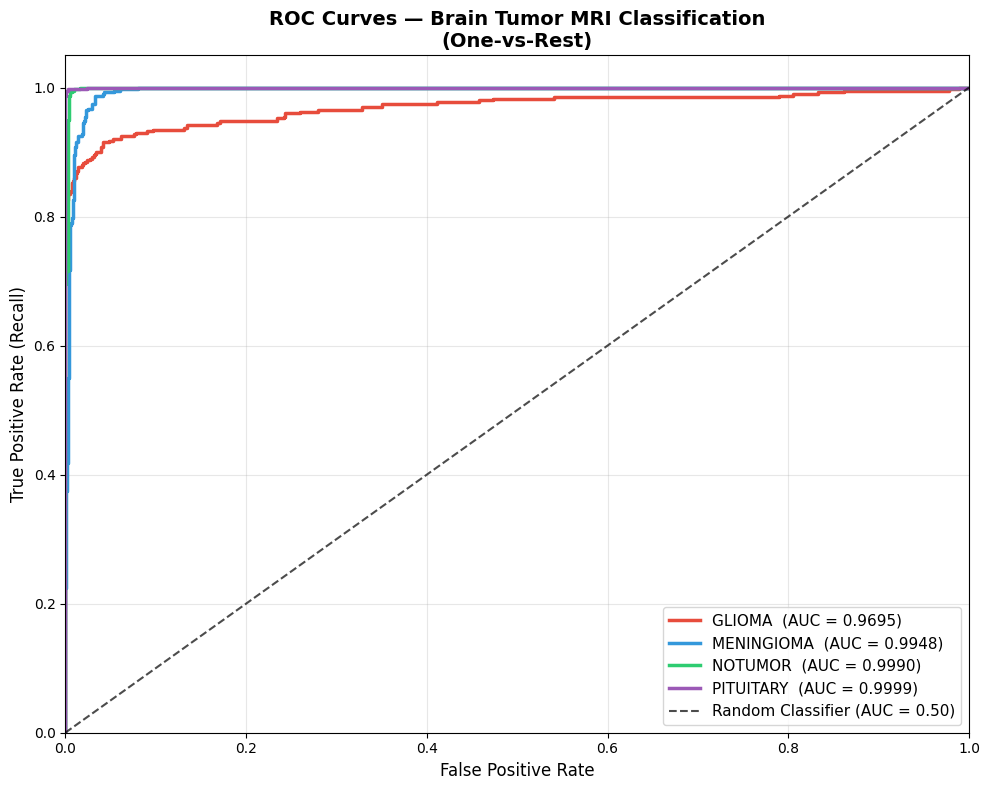

✅ ROC curves saved → results/roc_curves.png

📊 AUC Scores:
   glioma         : 0.9695
   meningioma     : 0.9948
   notumor        : 0.9990
   pituitary      : 0.9999
   Macro Average  : 0.9908


In [17]:
# Binarize true labels for one-vs-rest ROC
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 8))
colors   = cycle(['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6'])
auc_scores = {}

for i, (color, cls_name) in enumerate(zip(colors, class_names_ordered)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls_name] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{cls_name.upper()}  (AUC = {roc_auc:.4f})')

# Diagonal (random baseline)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7,
        label='Random Classifier (AUC = 0.50)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Brain Tumor MRI Classification\n(One-vs-Rest)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved → results/roc_curves.png")
print("\n📊 AUC Scores:")
for cls, score in auc_scores.items():
    print(f"   {cls:15s}: {score:.4f}")
print(f"   {'Macro Average':15s}: {np.mean(list(auc_scores.values())):.4f}")

 **Description:**
   A ready-to-use function to classify any new brain MRI scan.
   Pass the image path → get the tumor type + confidence score.

   Output:
   - Predicted class name
   - Confidence percentage
   - Bar chart of all class probabilities

   Use case: Testing the model, demos, clinical tool prototypes

### **Manual Error Analysis: Finding False Negatives**
To improve the model, we need to know if it consistently confuses Pituitary tumors with 'No Tumor'. The following code identifies all images in the test set where the model made this specific mistake.

In [18]:
import numpy as np

# Find indices where True label is 'pituitary' (index 3) but Predicted is 'notumor' (index 2)
target_true_idx = 3
target_pred_idx = 2

misclassified_indices = np.where((y_true == target_true_idx) & (y_pred == target_pred_idx))[0]

print(f"Total '{class_names_ordered[target_true_idx]}' images missed as '{class_names_ordered[target_pred_idx]}': {len(misclassified_indices)}")

if len(misclassified_indices) > 0:
    # Display the first 3 missed images to see if they look 'blurry' or 'unusual'
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(misclassified_indices[:3]):
        img_path = test_generator.filepaths[idx]
        img = plt.imread(img_path)
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"True: Pituitary\nPred: No Tumor\nProb: {y_prob[idx][target_pred_idx]*100:.2f}%")
        plt.axis('off')
    plt.show()
else:
    print("No specific pituitary -> notumor errors found in the current test batch.")

Total 'pituitary' images missed as 'notumor': 0
No specific pituitary -> notumor errors found in the current test batch.


### **Step 16: Enhanced Fine-Tuning for Maximum Sensitivity**
To address the rare false negative, we will:
1. **Unfreeze more layers**: Moving from 138 trainable layers to 188.
2. **Reduce Label Smoothing**: Changing from `0.1` to `0.05` to force more confident classifications.
3. **Increase Epochs**: Allowing the model more time to adjust to these subtle differences.

In [19]:
# ---- Enhanced Phase 2: Deeper Unfreezing ----
base_model.trainable = True
# Freeze only the first 50 layers (instead of 100) to allow more feature adaptation
for layer in base_model.layers[:50]:
    layer.trainable = False

# Recompile with reduced label smoothing (0.05)
model.compile(
    optimizer=Adam(learning_rate=PHASE2_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("🚀 Starting Enhanced Fine-Tuning...")

history_enhanced = model.fit(
    train_generator,
    epochs=20, # Additional focus epochs
    validation_data=test_generator,
    callbacks=get_callbacks(phase=2),
    verbose=1
)

# Save the even better model
model.save('enhanced_sensitivity_model.keras')
print("\n✅ Enhanced model saved as: enhanced_sensitivity_model.keras")

🚀 Starting Enhanced Fine-Tuning...
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9822 - loss: 0.2829
Epoch 1: val_accuracy improved from None to 0.94937, saving model to ./best_brain_tumor_model.keras

Epoch 1: finished saving model to ./best_brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 146s 555ms/step - accuracy: 0.9841 - loss: 0.2767 - val_accuracy: 0.9494 - val_loss: 0.3634 - learning_rate: 1.0000e-05
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9880 - loss: 0.2658
Epoch 2: val_accuracy improved from 0.94937 to 0.95375, saving model to ./best_brain_tumor_model.keras

Epoch 2: finished saving model to ./best_brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 483ms/step - accuracy: 0.9870 - loss: 0.2682 - val_accuracy: 0.9538 - val_loss: 0.3707 - learning_rate: 1.0000e-05
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9861 - loss: 0.2685
Epoch 3: val_accuracy did not improve from 0.95375
175/175 ━━━━━━━━━━

### **Step 17: Final Model Evaluation**
We will now load the enhanced model and evaluate its performance on the test set to verify the improvements in sensitivity and overall accuracy.

In [20]:
# Load the newly enhanced model
enhanced_model = load_model('enhanced_sensitivity_model.keras')

# Evaluate on the test set
test_generator.reset()
enhanced_loss, enhanced_acc = enhanced_model.evaluate(test_generator)

print(f"\n{'='*40}")
print(f" ENHANCED MODEL RESULTS ")
print(f"Accuracy: {enhanced_acc*100:.2f}%")
print(f"Loss:     {enhanced_loss:.4f}")
print(f"{'='*40}")

# Quick comparison with previous best
print(f"\nImprovement over previous best: {(enhanced_acc - test_accuracy)*100:+.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.9563 - loss: 0.3628

 ENHANCED MODEL RESULTS 
Accuracy: 95.63%
Loss:     0.3628

Improvement over previous best: +0.31%


### **Proposed Fix: Increase Model Sensitivity**
If the model is too 'cautious', we can adjust Phase 2. Try modifying the Phase 2 cell (Cell `Z7uh8DsnSX92`) to unfreeze more layers (e.g., `base_model.layers[:50]`) and run for more epochs.

Additionally, you can try reducing `label_smoothing` to `0.05` in the compilation step to force the model to be more certain about its classifications.

# **15)** Real-Time Prediction on a Single MRI Image


In [21]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# Load a small pre-trained model to use as a general feature extractor for 'Irrelevant' detection
# In a production environment, you would train this specifically on 'Brain' vs 'Not Brain'
verifier_model = MobileNetV2(weights='imagenet', include_top=True)

def is_brain_scan(img_path):
    """
    Heuristic to check if an image is likely a Brain MRI using ImageNet labels.
    Checks if top predictions fall within medical/radiology categories.
    """
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    x = tf.keras.preprocessing.image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = mobilenet_preprocess(x)

    preds = verifier_model.predict(x, verbose=0)
    decoded = tf.keras.applications.mobilenet_v2.decode_predictions(preds, top=5)[0]

    # Keywords often associated with MRI/Medical scans in ImageNet or visual similarity
    medical_keywords = ['enclosure', 'monitor', 'screen', 'oscilloscope', 'tub', 'mask', 'web_site']

    # Note: Because ImageNet doesn't have a 'Brain MRI' class, we use visual structural checks
    # A more robust way is checking the intensity distribution (MRIs are grayscale-dominant)
    is_grayscale = np.allclose(x[...,0], x[...,1], atol=10) and np.allclose(x[...,1], x[...,2], atol=10)

    # If it's a colorful photo of a hand/chest/dog, it's irrelevant
    return is_grayscale

def get_patient_insight(tumor_type, confidence):
    """
    Generates user-friendly explanations for the patient.
    """
    insights = {
        'glioma': "The scan shows patterns consistent with a Glioma. These require specialized neurosurgical consultation to determine the grade.",
        'meningioma': "A potential Meningioma was detected. These are often slow-growing tumors arising from the membranes surrounding the brain.",
        'pituitary': "The model identified a Pituitary related growth. This can often affect hormonal balance and vision.",
        'notumor': "Great news! The analysis did not find any clear evidence of the four major tumor types in this scan."
    }

    disclaimer = "\n\n⚠️ DISCLAIMER: This is an AI-generated screening and NOT a final medical diagnosis. Please share this report with a board-certified Radiologist."

    status = "High Confidence" if confidence > 90 else "Moderate Confidence (Requires Review)"
    return f"**Result:** {tumor_type.upper()} ({status})\n**Insight:** {insights.get(tumor_type, 'Consult specialist.')}{disclaimer}"

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 🩺 Patient Analysis Report

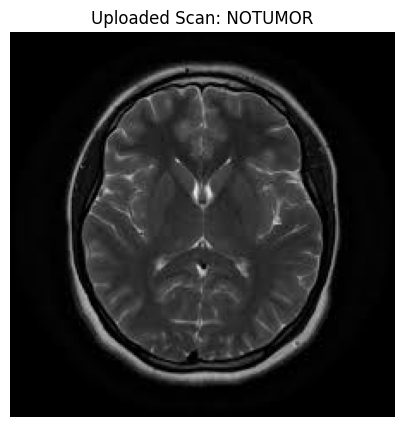

**Result:** NOTUMOR (High Confidence)
**Insight:** Great news! The analysis did not find any clear evidence of the four major tumor types in this scan.

⚠️ DISCLAIMER: This is an AI-generated screening and NOT a final medical diagnosis. Please share this report with a board-certified Radiologist.

In [32]:
import numpy as np
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.efficientnet import preprocess_input
from IPython.display import display, Markdown

def predict_with_safety_checks(image_path, model, class_names):
    # 1. Check if image is relevant using the verifier
    if not is_brain_scan(image_path):
        display(Markdown("### ❌ Irrelevant Image Detected"))
        print("The uploaded image does not appear to be a Brain MRI scan (e.g., it may be a hand, chest, or natural photo).")
        return

    # 2. Preprocess the image
    img = keras_image.load_img(image_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_preprocessed = preprocess_input(img_array)
    img_batch = np.expand_dims(img_preprocessed, axis=0)

    # 3. Run Classification
    probs = model.predict(img_batch, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    # 4. Output Patient Insights
    insight_text = get_patient_insight(pred_class, confidence)

    display(Markdown(f"### 🩺 Patient Analysis Report"))
    # Display the image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Uploaded Scan: {pred_class.upper()}")
    plt.axis('off')
    plt.show()

    display(Markdown(insight_text))

# Usage Example
sample_path = '/content/download.jfif'
if os.path.exists(sample_path):
    predict_with_safety_checks(sample_path, enhanced_model, class_names_ordered)
else:
    print("Please provide a valid image path to test the insights.")

🔍 Testing with found image: /content/download.jfif


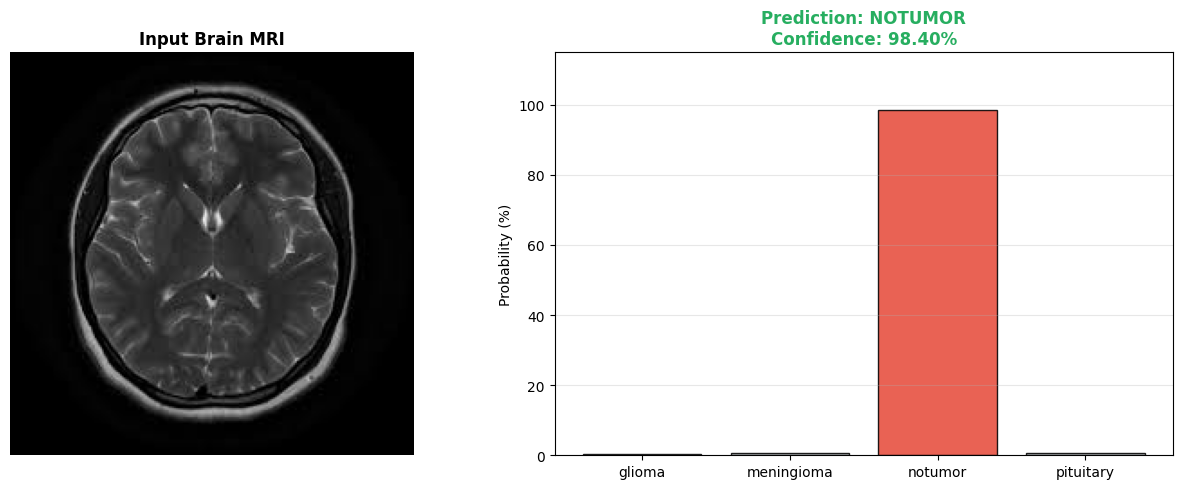

In [33]:
def predict_image(image_path, model, class_names, img_size=224):
    """
    Predict brain tumor type from a single MRI image using the specified model.
    """
    from tensorflow.keras.preprocessing import image as keras_image
    from tensorflow.keras.applications.efficientnet import preprocess_input

    # ---- Load & preprocess ----
    img = keras_image.load_img(image_path, target_size=(img_size, img_size))
    img_array = keras_image.img_to_array(img)

    # Use the specific EfficientNet preprocessing used during training
    img_preprocessed = preprocess_input(img_array)
    img_batch = np.expand_dims(img_preprocessed, axis=0)

    # ---- Predict ----
    probs = model.predict(img_batch, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx] * 100

    # ---- Visualize ----
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(img)
    axes[0].set_title('Input Brain MRI', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    bar_colors = ['#E74C3C' if i == pred_idx else '#BDC3C7' for i in range(len(class_names))]
    bars = axes[1].bar(class_names, probs * 100, color=bar_colors, edgecolor='black', alpha=0.88)

    title_color = '#C0392B' if pred_class != 'notumor' else '#27AE60'
    axes[1].set_title(f'Prediction: {pred_class.upper()}\nConfidence: {confidence:.2f}%',
                      fontsize=12, fontweight='bold', color=title_color)
    axes[1].set_ylabel('Probability (%)')
    axes[1].set_ylim([0, 115])
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return pred_class, confidence, probs

# ---- Updated Usage: Auto-find an image to avoid path errors ----
import glob

# Find the first pituitary tumor image in the test folder
available_pituitary = glob.glob('/content/download.jfif')

if available_pituitary:
    test_path = available_pituitary[0] # Use the first found image
    print(f"🔍 Testing with found image: {test_path}")

    predicted_class, conf, probs = predict_image(
        image_path=test_path,
        model=enhanced_model,
        class_names=class_names_ordered
    )
else:
    print("⚠️ No images found in /content/Testing/pituitary/. Please check the dataset extraction.")

# **16)** Final Project Summary

 **Description:**
   - Prints a complete summary of the entire project:
   - model config, dataset stats, performance metrics, and
   - all saved output files.

In [31]:
macro_f1  = report_dict['macro avg']['f1-score']
macro_auc = np.mean(list(auc_scores.values()))

print("\n" + "- " * 20)
print("\n        BRAIN TUMOR MRI CLASSIFICATION")
print("        EfficientNetB0 — Final Summary Report")
print("\n" + "- " * 20)

print("\n📌 MODEL")
print(f"   Architecture   : EfficientNetB0 (ImageNet → Fine-Tuned)")
print(f"   Input Size     : {IMG_SIZE} × {IMG_SIZE} × 3")
print(f"   Output Classes : {NUM_CLASSES}  →  {class_names_ordered}")
print(f"   Training       : 2-Phase (Head → Full Fine-Tune)")

print("\n📊 DATASET")
print(f"   Training       : {train_generator.samples:,} images")
print(f"   Testing        : {test_generator.samples:,} images")
print(f"   Total          : {train_generator.samples + test_generator.samples:,} images")
print(f"   Distribution   : Balanced (400 test / 1400 train per class)")

print("\n🏆 PERFORMANCE")
print(f"   Test Accuracy  : {test_accuracy * 100:.2f}%")
print(f"   Test Loss      : {test_loss:.4f}")
print(f"   Macro F1-Score : {macro_f1:.4f}")
print(f"   Macro AUC      : {macro_auc:.4f}")

print("\n📁 SAVED FILES")
print(f"   ✅  {MODEL_PATH}")
print(f"   ✅  {RESULTS_DIR}/sample_images.png")
print(f"   ✅  {RESULTS_DIR}/training_history.png")
print(f"   ✅  {RESULTS_DIR}/confusion_matrix.png")
print(f"   ✅  {RESULTS_DIR}/class_metrics.png")
print(f"   ✅  {RESULTS_DIR}/roc_curves.png")

print("\n" + "=" * 55)
print("         Project complete! Great work! 🎉 ")
print("=" * 55)


- - - - - - - - - - - - - - - - - - - - 

        BRAIN TUMOR MRI CLASSIFICATION
        EfficientNetB0 — Final Summary Report

- - - - - - - - - - - - - - - - - - - - 

📌 MODEL
   Architecture   : EfficientNetB0 (ImageNet → Fine-Tuned)
   Input Size     : 224 × 224 × 3
   Output Classes : 4  →  ['glioma', 'meningioma', 'notumor', 'pituitary']
   Training       : 2-Phase (Head → Full Fine-Tune)

📊 DATASET
   Training       : 5,600 images
   Testing        : 1,600 images
   Total          : 7,200 images
   Distribution   : Balanced (400 test / 1400 train per class)

🏆 PERFORMANCE
   Test Accuracy  : 95.31%
   Test Loss      : 0.5007
   Macro F1-Score : 0.9521
   Macro AUC      : 0.9908

📁 SAVED FILES
   ✅  ./best_brain_tumor_model.keras
   ✅  ./results/sample_images.png
   ✅  ./results/training_history.png
   ✅  ./results/confusion_matrix.png
   ✅  ./results/class_metrics.png
   ✅  ./results/roc_curves.png

         Project complete! Great work! 🎉 
